In [ ]:
! pip install numpy pandas matplotlib

## 7. 題目

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ |
|:----:|:-----:|:-----:|:-----:|:-----:|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | $-1$ | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Suppose we wish to use this data set to make a prediction for $Y$ when $X_1=X_2=X_3=0$ using $K$-nearest neighbors.

**(a)** Compute the Euclidean distance between each observation and the test point, $X_1=X_2=X_3=0$.

**(b)** What is our prediction with $K=1$? Why?

**(c)** What is our prediction with $K=3$? Why?

**(d)** If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for $K$ to be large or small? Why?

### (a) 解答

這一小題要計算觀測資料與測試點

$$
\mathbf{x}_0=(0,0,0)
$$

之間的歐氏距離。公式是

$$
d_i=\sqrt{(X_{i1}-0)^2+(X_{i2}-0)^2+(X_{i3}-0)^2}.
$$

定義 obs_n 與 test point 距離為 $d_n$ ，所以代入點可得

$$
\begin{aligned}
d_1 &= \sqrt{0^2+3^2+0^2}=3,\\
d_2 &= \sqrt{2^2+0^2+0^2}=2,\\
d_3 &= \sqrt{0^2+1^2+3^2}=\sqrt{10}\approx 3.162,\\
d_4 &= \sqrt{0^2+1^2+2^2}=\sqrt{5}\approx 2.236,\\
d_5 &= \sqrt{(-1)^2+0^2+1^2}=\sqrt{2}\approx 1.414,\\
d_6 &= \sqrt{1^2+1^2+1^2}=\sqrt{3}\approx 1.732.
\end{aligned}
$$


In [9]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    "observation": [1, 2, 3, 4, 5, 6],
    "X1": [0, 2, 0, 0, -1,1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"]
})

test_point = np.array([0, 0, 0])

# 可以用 data["distance"] = np.linalg.norm(data[["X1", "X2", "X3"]].to_numpy() - test_point, axis=1) 來計算
# np.linalg.norm() 用來計算向量長度，也就是歐氏距離
data["distance"] = np.sqrt((data["X1"] - test_point[0])**2 + (data["X2"] - test_point[1])**2 + (data["X3"] - test_point[2])**2)

print(data["distance"])

0    3.000000
1    2.000000
2    3.162278
3    2.236068
4    1.414214
5    1.732051
Name: distance, dtype: float64


### (b) 解答

當 $K=1$ 時，KNN 只使用距離測試點最近的一筆觀測資料進行分類。

由第 (a) 可知，距離 test point 最近的是第 5 筆觀測值：

$$
(X_1,X_2,X_3)=(-1,0,1),
$$

其距離為

$$
\sqrt{2}
\approx1.414.
$$

由於第 5 筆觀測值的類別為 Green，因此當 $K=1$ 時，測試點的預測類別為

$$
\hat{Y}=\text{Green}.
$$

In [10]:
# idxmin()：找出最小距離所在的資料列索引 
# loc[]：用索引來取出資料列

nearest_neighbor = data.loc[data["distance"].idxmin()]
prediction_k1 = nearest_neighbor["Y"]

print("K = 1 時的預測類別：", prediction_k1)

K = 1 時的預測類別： Green


### (c) 解答

當 $K=3$ 時，KNN 使用距離測試點最近的三筆觀測資料，並以多數決決定測試點的類別。

距離測試點 $(0,0,0)$ 最近的三筆觀測值為：

| 觀測值 | 距離 | 類別 |
|:------:|:-----------------------:|:-----:|
| 5 | $\sqrt{2}\approx1.414$ | Green |
| 6 | $\sqrt{3}\approx1.732$ | Red |
| 2 | $2$ | Red |

在這三個最近鄰中：

- Red 有 2 筆；
- Green 有 1 筆。

由於 Red 占多數，因此當 $K=3$ 時，測試點的預測類別為

$$
\hat{Y}=\text{Red}.
$$

In [11]:
# 給出距離最近三個點
three_nearest_neighbors = data.nsmallest(3, "distance")

# mode()：找出眾數
prediction_k3 = three_nearest_neighbors["Y"].mode().iloc[0]
print("K = 3 時的預測類別：", prediction_k3)

K = 3 時的預測類別： Red


### (d) 解答

較小的 $K$ 只使用測試點附近少數的觀測值進行分類，因此模型具有較高的彈性，可以產生較複雜且彎曲的決策邊界，從而捕捉資料中的局部非線性結構，可以從講義的圖看到 $k$ 比較小比較粗糙。

相反地，當 $K$ 較大時，模型會利用較大範圍內的觀測值進行多數決，使決策邊界變得較平滑。可以從講義中途看到平滑的示意圖，但這可能忽略資料中的局部變化，因而無法準確描述高度非線性的 Bayes 決策邊界。

因此如果 Bayes 決策邊界高度非線性，我覺得最佳的 $K$ 值較小。

## 8.題目

This exercise relates to the College data set, which can be found in the file `College.csv` on the book website. It contains a number of variables for 777 different universities and colleges in the US. The variables are

- `Private` : Public/private indicator
- `Apps` : Number of applications received
- `Accept` : Number of applicants accepted
- `Enroll` : Number of new students enrolled
- `Top10perc` : New students from top 10% of high school class
- `Top25perc` : New students from top 25% of high school class
- `F.Undergrad` : Number of full-time undergraduates
- `P.Undergrad` : Number of part-time undergraduates
- `Outstate` : Out-of-state tuition
- `Room.Board` : Room and board costs
- `Books` : Estimated book costs
- `Personal` : Estimated personal spending
- `PhD` : Percent of faculty with Ph.D.s
- `Terminal` : Percent of faculty with terminal degree
- `S.F.Ratio` : Student/faculty ratio
- `perc.alumni` : Percent of alumni who donate
- `Expend` : Instructional expenditure per student
- `Grad.Rate` : Graduation rate

Before reading the data into Python, it can be viewed in Excel or a text editor.

**(a)** Use the `pd.read_csv()` function to read the data into Python. Call the loaded data `college`. Make sure that you have the directory set to the correct location for the data.

**(b)** Look at the data used in the notebook by creating and running a new cell with just the code `college` in it. You should notice that the first column is just the name of each university in a column named something like `Unnamed: 0`. We don’t really want `pandas` to treat this as data. However, it may be handy to have these names for later. Try the following commands and similarly look at the resulting data frames:

```python
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'},
                          axis=1)
college3 = college3.set_index('College')
```

This has used the first column in the file as an index for the data frame. This means that `pandas` has given each row a name corresponding to the appropriate university. Now you should see that the first data column is `Private`. Note that the names of the colleges appear on the left of the table. We also introduced a new python object above: a dictionary, which is specified by `(key, value)` pairs. Keep your modified version of the data with the following:

```python
college = college3
```

**(c)** Use the `describe()` method of to produce a numerical summary of the variables in the data set.

**(d)** Use the `pd.plotting.scatter_matrix()` function to produce a scatterplot matrix of the first columns `[Top10perc, Apps, Enroll]`. Recall that you can reference a list `C` of columns of a data frame `A` using `A[C]`.

**(e)** Use the `boxplot()` method of `college` to produce side-by-side boxplots of `Outstate` versus `Private`.

**(f)** Create a new qualitative variable, called `Elite`, by binning the `Top10perc` variable into two groups based on whether or not the proportion of students coming from the top 10% of their high school classes exceeds 50%.

```python
college['Elite'] = pd.cut(college['Top10perc'],
                          [0,0.5,1],
                          labels=['No', 'Yes'])
```

Use the `value_counts()` method of `college['Elite']` to see how many elite universities there are. Finally, use the `boxplot()` method again to produce side-by-side boxplots of `Outstate` versus `Elite`.

**(g)** Use the `plot.hist()` method of `college` to produce some histograms with differing numbers of bins for a few of the quantitative variables. The command `plt.subplots(2, 2)` may be useful: it will divide the plot window into four regions so that four plots can be made simultaneously. By changing the arguments you can divide the screen up in other combinations.

**(h)** Continue exploring the data, and provide a brief summary of what you discover.

### (a) 解答

In [12]:
import pandas as pd

college = pd.read_csv("data/College.csv")
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


### (b) 解答

原始資料的第一欄為 `Unnamed: 0`，其內容是每所大學的名稱，而不是一個用於分析的變數。因此，應將這一欄設定為 DataFrame 的索引。

第一種方法是在使用 `pd.read_csv()` 讀取資料時，透過 `index_col=0` 直接將第一欄指定為索引。
第二種方法是先將第一欄改名為 College，再設為索引

In [ ]:
# 方法一：讀取資料時，直接將第一欄設為索引
# index_col=0 直接把 CSV 的第 1 欄當作索引。
college2 = pd.read_csv("data/College.csv", index_col=0)

# 方法二：先將第一欄改名為 College，再設為索引
# axis=1 代表修改欄位名稱
college3 = college.rename(
    {"Unnamed: 0": "College"},
    axis=1
)

# 讓大學取代原先 index 不會被誤認為要分析的變數
college3 = college3.set_index("College")

college = college3

### (c) 解答

使用 `describe()` 方法計算 College 資料集中所有數值變數的有效觀測值數量、平均數、標準差、最小值、四分位數及最大值

In [14]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### (d) 解答

使用 `pd.plotting.scatter_matrix()` 繪製 `Top10perc`、`Apps` 與 `Enroll` 三個變數的散布圖矩陣，以觀察各變數的分布及其兩兩之間的關係。

從散布圖可以看出，`Apps` 與 `Enroll` 之間具有明顯的正向關係：收到申請人數較多的學校，通常也有較多的新生入學。`Top10perc` 與另外兩個變數之間的關係則較為分散，線性關係沒有 `Apps` 與 `Enroll` 之間明顯。此外，`Apps` 和 `Enroll` 的分布皆呈現右偏，表示大多數學校的申請及入學人數較少，但少數大型學校的人數非常高。

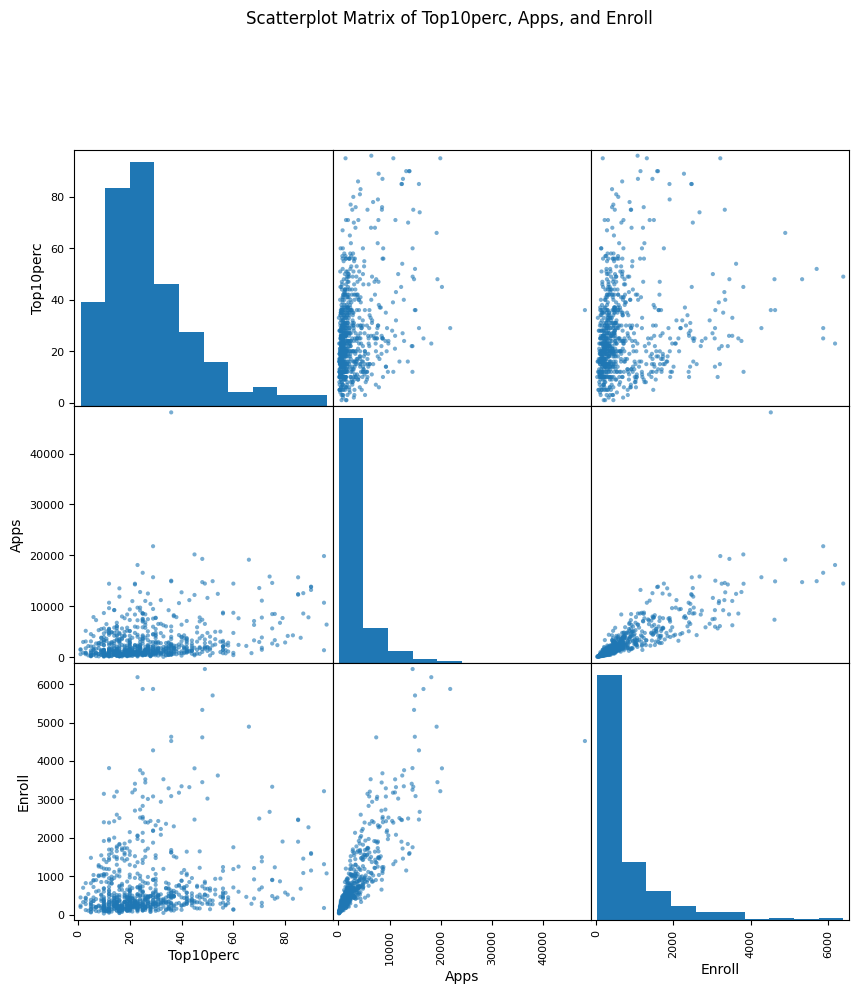

In [ ]:
import matplotlib.pyplot as plt

columns = ["Top10perc", "Apps", "Enroll"]

# scatter_matrix 會一次畫出所有變數兩兩之間的散布圖，自己對自己沒意義所以戶畫直方圖表示自己分布情況
pd.plotting.scatter_matrix(
    college[columns],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.6
)

plt.suptitle(
    "Scatterplot Matrix of Top10perc, Apps, and Enroll",
    y=1.02
)

plt.show()

### (e) 解答

使用並列箱型圖比較公立學校與私立學校的外州學生學費分布，其中 `Private = Yes` 代表私立學校，`Private = No` 代表公立學校。

從箱型圖可以看出，私立學校的外州學生學費中位數明顯高於公立學校，且私立學校的學費分布整體位於較高的位置。雖然兩組學費仍有部分重疊，但學校是否為私立與外州學生學費之間存在明顯關聯；整體而言，私立學校的外州學生學費較高。

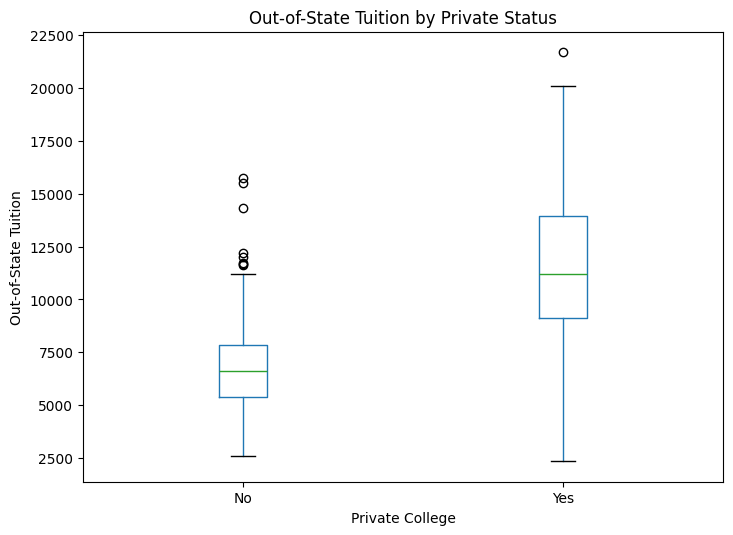

In [16]:
college.boxplot(
    column="Outstate",
    by="Private",
    figsize=(8, 6),
    grid=False
)

plt.title("Out-of-State Tuition by Private Status")
plt.suptitle("")
plt.xlabel("Private College")
plt.ylabel("Out-of-State Tuition")
plt.show()

### (f) 解答

根據 `Top10perc` 建立新的質性變數 `Elite`。若一所學校的新生中，來自高中班級前 10% 的比例超過 50%，則將該學校分類為 `Elite = Yes`；否則分類為 `Elite = No`。

結果顯示，資料集中共有 78 所 Elite 學校及 699 所非 Elite 學校。從並列箱型圖可以看出，Elite 學校的外州學生學費中位數明顯高於非 Elite 學校，且整體學費分布也位於較高的位置。因此，Elite 學校通常具有較高的外州學生學費。

In [22]:
college["Top10perc"].min(), college["Top10perc"].max()

(np.int64(1), np.int64(96))

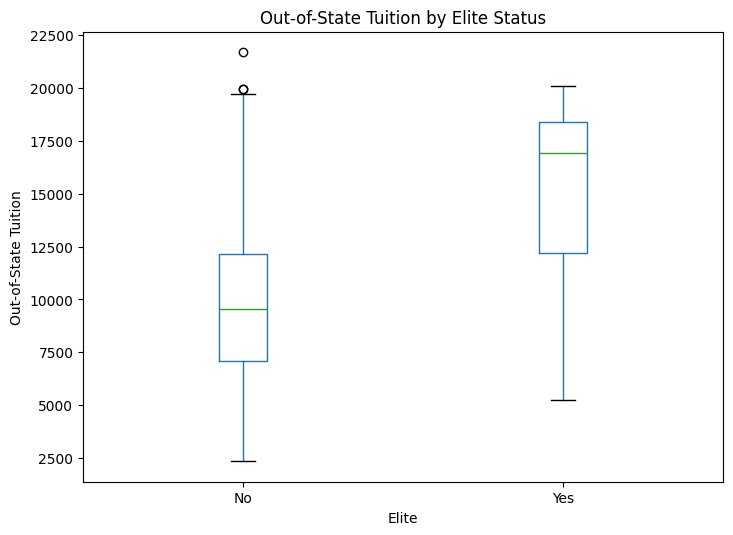

In [ ]:
# 確認最大值以及最低值方便後續切割，最小 1 最大 96
college["Top10perc"].min(), college["Top10perc"].max()

college["Elite"] = pd.cut(
    college["Top10perc"],
    bins=[0, 50, 100],
    labels=["No", "Yes"]
)

# 計算兩組學校數量
college["Elite"].value_counts()

college.boxplot(
    column="Outstate",
    by="Elite",
    figsize=(8, 6),
    grid=False
)

plt.title("Out-of-State Tuition by Elite Status")
plt.suptitle("")
plt.xlabel("Elite")
plt.ylabel("Out-of-State Tuition")
plt.show()

## 9.題目

This exercise involves the Auto data set studied in the lab. Make sure that the missing values have been removed from the data.

**(a)** Which of the predictors are quantitative, and which are qualitative?

**(b)** What is the range of each quantitative predictor? You can answer this using the `min()` and `max()` methods in `numpy`.

**(c)** What is the mean and standard deviation of each quantitative predictor?

**(d)** Now remove the 10th through 85th observations. What is the range, mean, and standard deviation of each predictor in the subset of the data that remains?

**(e)** Using the full data set, investigate the predictors graphically, using scatterplots or other tools of your choice. Create some plots highlighting the relationships among the predictors. Comment on your findings.

**(f)** Suppose that we wish to predict gas mileage (`mpg`) on the basis of the other variables. Do your plots suggest that any of the other variables might be useful in predicting `mpg`? Justify your answer.

## 10.題目

This exercise involves the Boston housing data set.

**(a)** To begin, load in the Boston data set, which is part of the `ISLP` library.

**(b)** How many rows are in this data set? How many columns? What do the rows and columns represent?

**(c)** Make some pairwise scatterplots of the predictors (columns) in this data set. Describe your findings.

**(d)** Are any of the predictors associated with per capita crime rate? If so, explain the relationship.

**(e)** Do any of the suburbs of Boston appear to have particularly high crime rates? Tax rates? Pupil-teacher ratios? Comment on the range of each predictor.

**(f)** How many of the suburbs in this data set bound the Charles river?

**(g)** What is the median pupil-teacher ratio among the towns in this data set?

**(h)** Which suburb of Boston has lowest median value of owner-occupied homes? What are the values of the other predictors for that suburb, and how do those values compare to the overall ranges for those predictors? Comment on your findings.

**(i)** In this data set, how many of the suburbs average more than seven rooms per dwelling? More than eight rooms per dwelling? Comment on the suburbs that average more than eight rooms per dwelling.